In [0]:
dbutils.library.restartPython()

# Genomic prediction for potato aroma traits (model comparison )


This notebook evaluates how predictable each aroma/VOC trait is from genotype (taglotype markers), using **nested cross-validation** and a consistent GWAS-guided feature selection strategy. It compares three model families:
- **Linear models** (OLS, Ridge, Lasso, ElasticNet)
- **Kernel Ridge Regression (KRR, RBF kernel)**
- **Nonlinear models** (SVR, Random Forest, XGBoost when available)

For each trait, the workflow:
1) selects top GWAS markers (top `n_snps` per trait),
2) applies LD-style pruning by correlation threshold (`prune_threshold`) within CV folds,
3) runs nested-CV model training/evaluation (no-leak preprocessing),
4) stores all results as CSV and produces report-ready plots.




# Loading config

In [0]:
import yaml
import pandas as pd
from pyspark.sql import functions as F, Window
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from gene_marker import run_linear_models_cv_nested_light_fast
from pyspark.sql.window import Window
from pyspark.sql import functions as F
import mlflow
import mlflow.sklearn
import os
from datetime import datetime
import importlib
import gene_marker
importlib.reload(gene_marker)
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from gene_marker import (
    run_krr_models_cv_nested_light_noleak,
    run_nonlinear_models_cv_nested_light_noleak,
)
import os, glob
from pathlib import Path
from datetime import datetime
import yaml
import mlflow 

In [0]:

CONFIG_PATH = "/Volumes/bmqg/default_bronze/fatemeh/config_mixed.yaml"


with open(CONFIG_PATH) as f:
    CONFIG = yaml.safe_load(f)


# Loading  data

In [0]:
PHENO_PATH = CONFIG["paths"]["aroma_matrix_newharvested"]
GWAS_TABLE = CONFIG["data"]["gwas_table_newharvested"]

print("Phenotype file:", PHENO_PATH)
print("GWAS table:", GWAS_TABLE)

GWAS_TABLE_NEW = CONFIG["data"]["gwas_table_newharvested"]

Phenotype file: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/matched_per_variety_STRICT_ONLY.csv
GWAS table: DataFrame[rs: string, chr: int, ps: int, n_miss: int, allele1: string, allele0: int, af: float, beta: float, se: float, logl_H1: float, l_remle: float, p_wald: float, chrom: string, start: string, taglo_id1: string, taglo_id2: string, taglo_id3: string, taglo_id4: string, allele_freq: string, count_0: string, trait: string]


# Build a Top-Taglotype GWAS Summary Table (Trait × Taglo ID) by Exploding Multi-Taglo Hits and Keeping the Top 200 per Trait

In [0]:


PH = pd.read_csv(PHENO_PATH)
PH = PH.set_index("Variety")

traits = [str(c) for c in PH.columns]


# =========================
# 3. Prefilter GWAS
# =========================
gwas_prefilter = (
    GWAS_TABLE
    .filter(F.col("trait").isin(traits))
    .filter(F.col("p_wald") < 1e-4)
    .select(
        F.col("trait").cast("string").alias("Trait"),
        F.col("p_wald").cast("double").alias("p_value"),

        #  cast SNPs to string (critical)
        F.col("taglo_id1").cast("string"),
        F.col("taglo_id2").cast("string"),
        F.col("taglo_id3").cast("string"),
        F.col("taglo_id4").cast("string"),
    )
)

# =========================
# 4. Convert to long format
# =========================
gwas_long = (
    gwas_prefilter
    .select(
        "Trait",
        "p_value",
        F.explode(
            F.array("taglo_id1", "taglo_id2", "taglo_id3", "taglo_id4")
        ).alias("SNP")
    )
    .dropna(subset=["SNP", "p_value"])
)

# =========================
# 5. Keep best p-value per SNP
# =========================
gwas_long_best = (
    gwas_long
    .groupBy("Trait", "SNP")
    .agg(F.min("p_value").alias("p_value"))
)

# =========================
# 6. Top SNPs per trait
# =========================
top_rows_per_trait = 200

gwas_long_limited = (
    gwas_long_best
    .withColumn(
        "rn",
        F.row_number().over(
            Window.partitionBy("Trait").orderBy(F.col("p_value").asc())
        )
    )
    .filter(F.col("rn") <= top_rows_per_trait)
    .drop("rn")
)

# =========================
# 7. Inspect
# =========================
display(gwas_long_limited.limit(5))
print("Total rows:", gwas_long_limited.count())

GWAS columns: ['rs', 'chr', 'ps', 'n_miss', 'allele1', 'allele0', 'af', 'beta', 'se', 'logl_H1', 'l_remle', 'p_wald', 'chrom', 'start', 'taglo_id1', 'taglo_id2', 'taglo_id3', 'taglo_id4', 'allele_freq', 'count_0', 'trait']


Trait,SNP,p_value
1-Octen-3-ol,0,4.7856129725687424E-8
1-Octen-3-ol,146330,4.7856129725687424E-8
1-Octen-3-ol,16443,4.8248061546019017E-8
1-Octen-3-ol,16444,4.8248061546019017E-8
1-Octen-3-ol,11481,4.8248061546019017E-8


Total rows: 7523


# Linear model predictions

In [0]:

# =========================
# 1. Disable MLflow
# =========================
mlflow.autolog(disable=True)
mlflow.sklearn.autolog(disable=True)

# =========================
# 2. GWAS: Top SNPs
# =========================
w = Window.partitionBy("Trait").orderBy("p_value")

gwas_slim = (
    gwas_long_limited
    .withColumn("rn", F.row_number().over(w))
    .filter(F.col("rn") <= 200)
    .select("Trait", "SNP", "p_value")
    .cache()
)

_ = gwas_slim.count()
gwas_pd = gwas_slim.toPandas()

# =========================
# 3. GT: Spark → pandas
# =========================
GT = tg.toPandas()

# =========================
# 4. PIVOT (CRITICAL)
# =========================
if {"Variety", "taglo_id", "value"}.issubset(GT.columns):
    print("Pivoting GT (long → wide)...")
    GT = GT.pivot(index="Variety", columns="taglo_id", values="value")
else:
    raise ValueError(f"Unexpected GT columns: {GT.columns.tolist()}")

# =========================
# 5. CLEAN TYPES
# =========================
GT = GT.fillna(0)
GT.columns = GT.columns.astype(str)
gwas_pd["SNP"] = gwas_pd["SNP"].astype(str)

# =========================
# 6. SNP OVERLAP
# =========================
common_snps = list(set(GT.columns) & set(gwas_pd["SNP"]))

print("Common SNPs:", len(common_snps))

if len(common_snps) == 0:
    raise ValueError("No overlapping SNPs")

GT = GT[common_snps]
gwas_pd = gwas_pd[gwas_pd["SNP"].isin(common_snps)]

# =========================
# 7. ALIGN SAMPLES
# =========================
common_samples = GT.index.intersection(PH.index)

GT = GT.loc[common_samples]
PH = PH.loc[common_samples]

print("Samples:", len(common_samples))

if len(common_samples) == 0:
    raise ValueError("No matching samples")

# =========================
# 8. FEATURE SCALING (CRITICAL FIX)
# =========================
from sklearn.preprocessing import StandardScaler

print("Scaling features...")
scaler = StandardScaler()

GT = pd.DataFrame(
    scaler.fit_transform(GT),
    index=GT.index,
    columns=GT.columns
)

# =========================
# 9. REMOVE LOW VARIANCE SNPs
# =========================
print("Removing low-variance SNPs...")

var = GT.var(axis=0)
GT = GT.loc[:, var > 0.01]

print("GT shape after filtering:", GT.shape)

# =========================
# 10. PARAMETERS
# =========================
N_SNPS_LIST = [20, 50, 100, 150, 200]
PRUNE_LIST  = [0.90, 0.95, 0.98]

all_runs = []

# =========================
# 11. SAFE RUN
# =========================
def safe_run(**kwargs):
    try:
        df = run_linear_models_cv_nested_light_fast(**kwargs)
        if df is None or df.empty:
            print("Empty result")
            return None
        return df
    except Exception as e:
        print("Error:", e)
        return None

# =========================
# 12. GRID SEARCH
# =========================
for prune in PRUNE_LIST:
    for n_snps in N_SNPS_LIST:

        print(f"\n=== Running: n_snps={n_snps}, prune={prune} ===")

        n_snps_adj = min(n_snps, len(GT.columns))

        if n_snps_adj < 5:
            print("Too few SNPs, skipping...")
            continue

        df = safe_run(
            gwas_df=gwas_pd,
            GT=GT,
            PH=PH,
            n_snps=n_snps_adj,
            prune_threshold=prune,
            n_splits=3,
            inner_splits=2,
            random_state=42,
            max_iter=20000,   # increased for convergence
            verbose_every=0,
        )

        if df is None:
            continue

        df["n_snps"] = n_snps_adj
        df["prune_threshold"] = prune
        all_runs.append(df)

# =========================
# 13. COMBINE RESULTS
# =========================
if all_runs:
    df_grid = pd.concat(all_runs, ignore_index=True)
else:
    df_grid = pd.DataFrame()
    print("No successful runs")

display(df_grid.head())

# =========================
# 14. SAVE
# =========================
out_dir = "/Volumes/bmqg/default_bronze/fatemeh/final_project/model_results"
os.makedirs(out_dir, exist_ok=True)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = os.path.join(out_dir, f"linear_grid_{ts}.csv")

df_grid.to_csv(csv_path, index=False)

print("Saved CSV:", csv_path)

Pivoting GT (long → wide)...
Common SNPs: 4747
Samples: 95
Scaling features...
Removing low-variance SNPs...
GT shape after filtering: (95, 4742)

=== Running: n_snps=20, prune=0.9 ===
Empty result

=== Running: n_snps=50, prune=0.9 ===


/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.593e+11, tolerance: 5.449e+09
  model = cd_fast.enet_coordinate_descent(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.450e+10, tolerance: 2.611e+09
  model = cd_fast.enet_coordinate_descent(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.58


=== Running: n_snps=100, prune=0.9 ===


/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.804e+10, tolerance: 5.449e+09
  model = cd_fast.enet_coordinate_descent(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.289e+11, tolerance: 2.611e+09
  model = cd_fast.enet_coordinate_descent(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.61


=== Running: n_snps=150, prune=0.9 ===


...

/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.941e+11, tolerance: 8.587e+09
  model = cd_fast.enet_coordinate_descent(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.566e+11, tolerance: 9.667e+09
  model = cd_fast.enet_coordinate_descent(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.16


=== Running: n_snps=200, prune=0.98 ===


/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.481e+07, tolerance: 1.943e+06
  model = cd_fast.enet_coordinate_descent(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.451e+07, tolerance: 2.726e+06
  model = cd_fast.enet_coordinate_descent(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.24

Trait,Model,CV_R2,RMSE,MAE,n_snps,prune_threshold
(E)-2-Decenal,OLS,-0.7378675332258671,1496238.6185063503,1072297.0307077966,50,0.9
(E)-2-Decenal,Ridge,-0.16900476574228906,1227158.516647495,947348.8885446641,50,0.9
(E)-2-Decenal,Lasso,-0.7581639139548051,1504950.466568999,1084352.5125766925,50,0.9
(E)-2-Decenal,ElasticNet,-0.23595891474366826,1261811.6770272586,973980.4991594183,50,0.9
"1-Hexanol, 2-ethyl-",OLS,-0.7378675332258615,1496238.6185063478,1072297.030707796,50,0.9


Saved CSV: /Volumes/bmqg/default_bronze/fatemeh/final_project/model_results/linear_grid_20260320_191503.csv


In [0]:
best_per_trait = (
    df_grid.sort_values("CV_R2", ascending=False)
    .groupby("Trait", as_index=False)
    .head(1)
)

display(best_per_trait.sort_values("CV_R2", ascending=False))


Trait,Model,CV_R2,RMSE,MAE,n_snps,prune_threshold
"Butanal, 3-methyl-",Ridge,0.7893224352592978,54897.06163064037,36670.04580171102,100,0.9
Benzaldehyde,Ridge,0.6464036347922737,376746.8740547328,278191.802431894,200,0.95
Decanal,Ridge,0.610957297647919,178516.5278966697,118236.24863954113,50,0.98
Dimethyl disulfide,Ridge,0.5956648867683514,176609.5318305015,130735.83292730582,100,0.9
3-Carene,Ridge,0.5762297095733413,16129.640928064235,11925.844896650378,200,0.9
Dimethyl phthalate,OLS,0.5531377434845741,757290.7204484397,321452.53114454675,50,0.9
Phenol,Ridge,0.5288947190940116,28519.079931291282,22965.415502669857,150,0.95
Tetradecane,Ridge,0.5093781035120137,125738.61589956714,98823.79575183107,200,0.9
"Acetic acid, methyl ester",Ridge,0.4770584935302272,227632.82184721177,190024.587171719,100,0.9
1-Octen-3-ol,Ridge,0.46996427699117016,17512.560251635303,12863.784964488746,150,0.9


# Visualizing linear model results

Trait,Model,CV_R2,RMSE,MAE,n_snps,prune_threshold
(E)-2-Decenal,OLS,-0.7378675332258671,1496238.6185063503,1072297.0307077966,50,0.9
(E)-2-Decenal,Ridge,-0.169004765742289,1227158.516647495,947348.888544664,50,0.9
(E)-2-Decenal,Lasso,-0.7581639139548051,1504950.466568999,1084352.5125766925,50,0.9
(E)-2-Decenal,ElasticNet,-0.2359589147436682,1261811.6770272586,973980.4991594184,50,0.9
"1-Hexanol, 2-ethyl-",OLS,-0.7378675332258615,1496238.6185063478,1072297.030707796,50,0.9


shape: (1776, 7) | models: ['ElasticNet', 'Lasso', 'OLS', 'Ridge']


<Figure size 900x500 with 0 Axes>

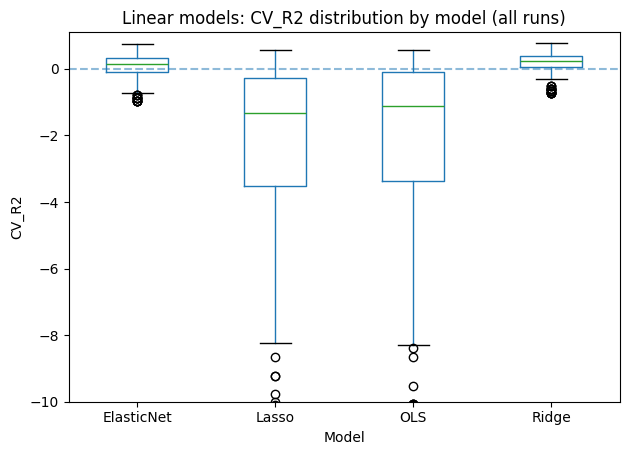

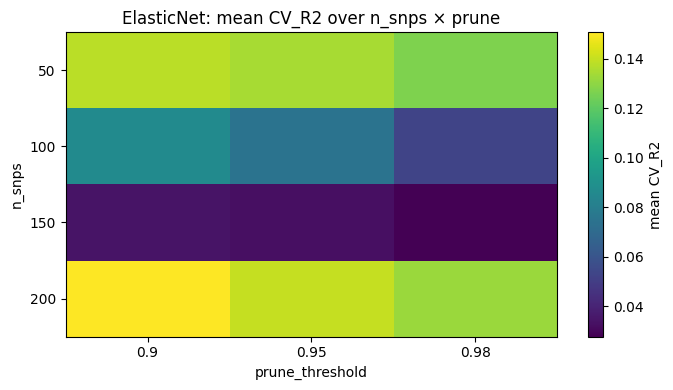

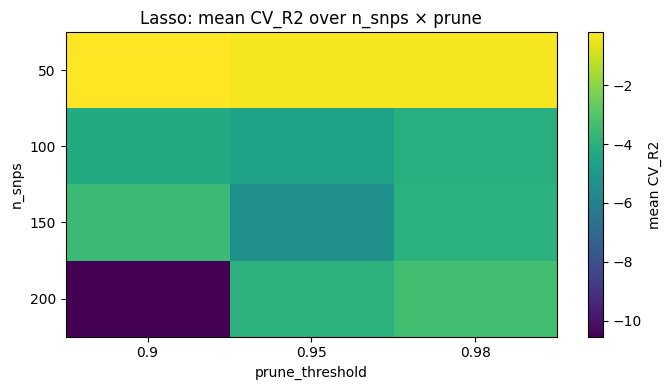

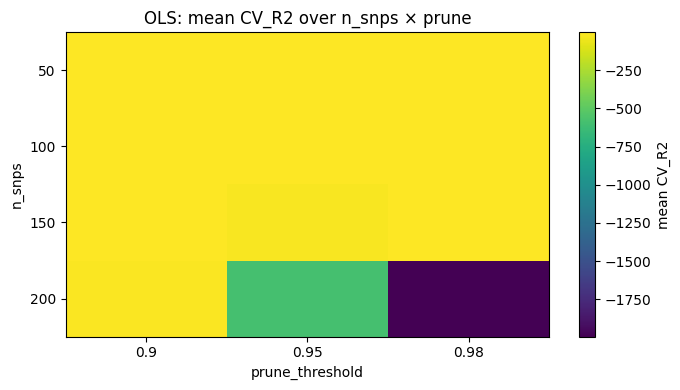

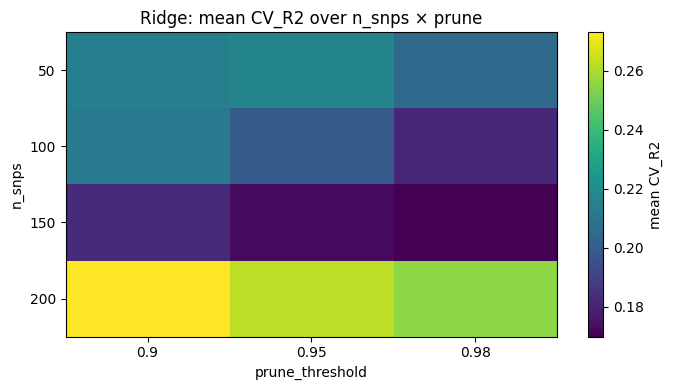

Model,n_snps,prune_threshold,CV_R2
Ridge,200,0.9,0.2730322078053449
Ridge,200,0.95,0.26259341306966977
Ridge,200,0.98,0.255306894706313
Ridge,50,0.95,0.2167064893285662
Ridge,50,0.9,0.21429745453190494
Ridge,100,0.9,0.21206119042563484
Ridge,50,0.98,0.20556048110171507
Ridge,100,0.95,0.1993333514297546
Ridge,150,0.9,0.1820239648804586
Ridge,100,0.98,0.18134483133032034


Trait,Model,CV_R2,RMSE,MAE,n_snps,prune_threshold
"Butanal, 3-methyl-",Ridge,0.7893224352592978,54897.06163064037,36670.04580171102,100,0.9
Benzaldehyde,Ridge,0.6464036347922737,376746.8740547328,278191.802431894,200,0.95
Decanal,Ridge,0.610957297647919,178516.5278966697,118236.24863954113,50,0.95
Dimethyl disulfide,Ridge,0.5956648867683514,176609.5318305015,130735.83292730582,100,0.9
3-Carene,Ridge,0.5762297095733413,16129.640928064237,11925.844896650378,200,0.9
Dimethyl phthalate,OLS,0.5531377434845741,757290.7204484397,321452.53114454675,50,0.9
Phenol,Ridge,0.5288947190940116,28519.07993129128,22965.415502669857,150,0.95
Tetradecane,Ridge,0.5093781035120137,125738.61589956714,98823.79575183109,200,0.9
"Acetic acid, methyl ester",Ridge,0.4770584935302272,227632.82184721177,190024.587171719,100,0.9
1-Octen-3-ol,Ridge,0.4699642769911701,17512.560251635303,12863.784964488745,100,0.9


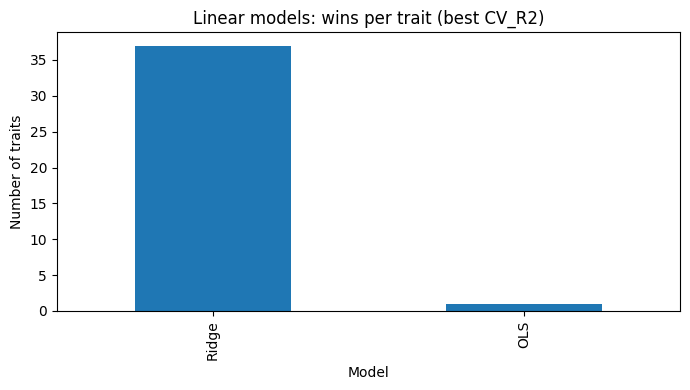

In [0]:

path = "/Volumes/bmqg/default_bronze/fatemeh/final_project/model_results/linear_grid_20260319_231821.csv"
df = pd.read_csv(path)

# clean + ensure numeric
for c in ["CV_R2","RMSE","MAE"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan)

display(df.head())
print("shape:", df.shape, "| models:", sorted(df["Model"].unique()))

# 1) Boxplot: CV_R2 by model (all runs pooled)
plt.figure(figsize=(9,5))
df.boxplot(column="CV_R2", by="Model", grid=False)
plt.axhline(0, linestyle="--", alpha=0.5)
plt.title("Linear models: CV_R2 distribution by model (all runs)")
plt.suptitle("")
plt.ylabel("CV_R2")
plt.ylim(-10, 1.1)
plt.xlabel("Model")
plt.tight_layout()
plt.show()

# 2) Heatmap helper: mean metric over (n_snps x prune_threshold) per model
def heatmap_mean(df, model, metric="CV_R2"):
    if not {"n_snps","prune_threshold",metric}.issubset(df.columns):
        print("Missing columns for heatmap. Need: n_snps, prune_threshold,", metric)
        return
    
    g = (df[df["Model"] == model]
         .groupby(["n_snps","prune_threshold"])[metric]
         .mean()
         .reset_index())
    pv = g.pivot(index="n_snps", columns="prune_threshold", values=metric).sort_index()
    Z = pv.to_numpy()

    plt.figure(figsize=(7,4))
    plt.imshow(Z, aspect="auto")
    plt.xticks(range(len(pv.columns)), pv.columns, rotation=0)
    plt.yticks(range(len(pv.index)), pv.index)
    plt.colorbar(label=f"mean {metric}")
    plt.xlabel("prune_threshold")
    plt.ylabel("n_snps")
    plt.title(f"{model}: mean {metric} over n_snps × prune")
    plt.tight_layout()
    plt.show()

# 2a) Heatmaps for each linear model (CV_R2)
for m in sorted(df["Model"].unique()):
    heatmap_mean(df, m, metric="CV_R2")

# 3) Best setting per model (by mean CV_R2 across traits)
best_setting = (df.groupby(["Model","n_snps","prune_threshold"])["CV_R2"]
                  .mean()
                  .reset_index()
                  .sort_values("CV_R2", ascending=False))
display(best_setting.head(20))

# 4) Best row per trait (winner across all settings/models)
best_per_trait = (df.loc[df.groupby("Trait")["CV_R2"].idxmax()]
                    .sort_values("CV_R2", ascending=False)
                    .reset_index(drop=True))
display(best_per_trait.head(20))

# 5) Win count: which model wins most traits?
win_counts = best_per_trait["Model"].value_counts()
plt.figure(figsize=(7,4))
win_counts.plot(kind="bar")
plt.title("Linear models: wins per trait (best CV_R2)")
plt.ylabel("Number of traits")
plt.tight_layout()
plt.show()


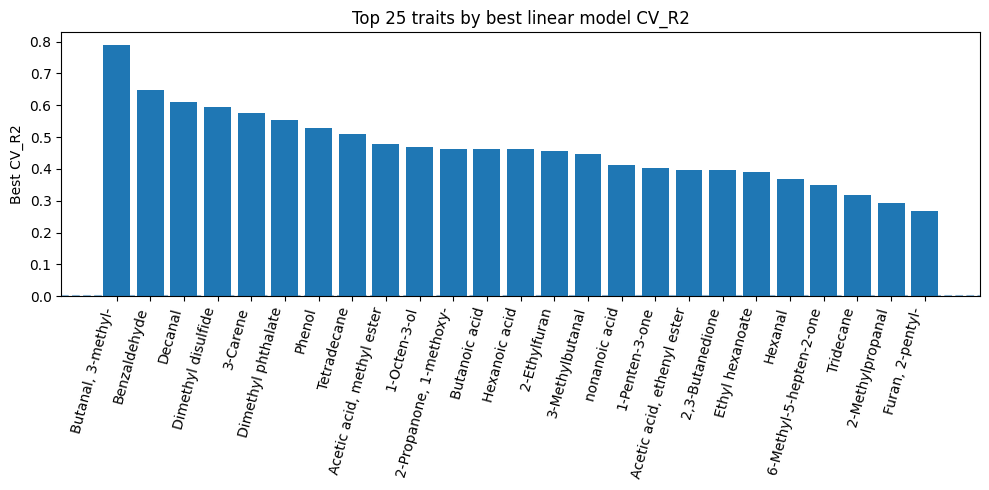

In [0]:
best = df.loc[df.groupby("Trait")["CV_R2"].idxmax()].sort_values("CV_R2", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(best["Trait"].head(25), best["CV_R2"].head(25))
plt.axhline(0, linestyle="--", alpha=0.5)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Best CV_R2")
plt.title("Top 25 traits by best linear model CV_R2")
plt.tight_layout()
plt.show()


# KRR model prediction

In [0]:


N_SNPS_LIST = [20, 50, 100, 150, 200]
PRUNE_LIST  = [0.90, 0.95, 0.98]

all_runs = []

for prune in PRUNE_LIST:
    for n_snps in N_SNPS_LIST:

        print(f"\n=== Running: n_snps={n_snps}, prune={prune} ===")

        n_snps_adj = min(n_snps, GT.shape[1])

        if n_snps_adj < 5:
            print("Too few SNPs after pruning, skipping")
            continue

        try:
            df_krr = run_krr_models_cv_nested_light_noleak(
                gwas_df=gwas_pd,
                GT=GT,
                PH=PH,
                n_snps=n_snps_adj,   # 
                prune_threshold=prune,
                n_splits=3,
                inner_splits=3,
                random_state=42,
            )

            if df_krr is None or len(df_krr) == 0:
                print("Returned empty result")
                continue

            df_krr = df_krr.copy()
            df_krr["n_snps"] = n_snps_adj
            df_krr["prune_threshold"] = prune

            all_runs.append(df_krr)

        except Exception as e:
            print(f"Failed for n_snps={n_snps}, prune={prune}: {e}")
            continue

# =========================
# RESULTS
# =========================
if len(all_runs) == 0:
    raise RuntimeError("No runs succeeded — check model function or scaling")

results = pd.concat(all_runs, ignore_index=True)

print("results shape:", results.shape)
display(results.sort_values("CV_R2", ascending=False).head(20))

# =========================
# SAVE
# =========================
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

csv_path = os.path.join(out_dir, f"krr_grid_{ts}.csv")
results.to_csv(csv_path, index=False)

print("Saved CSV:", csv_path)


=== Running: n_snps=20, prune=0.9 ===
Returned empty result

=== Running: n_snps=50, prune=0.9 ===

=== Running: n_snps=100, prune=0.9 ===

=== Running: n_snps=150, prune=0.9 ===

=== Running: n_snps=200, prune=0.9 ===

=== Running: n_snps=20, prune=0.95 ===
Returned empty result

=== Running: n_snps=50, prune=0.95 ===

=== Running: n_snps=100, prune=0.95 ===

=== Running: n_snps=150, prune=0.95 ===

=== Running: n_snps=200, prune=0.95 ===

=== Running: n_snps=20, prune=0.98 ===
Returned empty result

=== Running: n_snps=50, prune=0.98 ===

=== Running: n_snps=100, prune=0.98 ===

=== Running: n_snps=150, prune=0.98 ===

=== Running: n_snps=200, prune=0.98 ===
results shape: (389, 7)


Trait,Model,CV_R2,RMSE,MAE,n_snps,prune_threshold
Phenol,KRR_RBF,0.49453453875304565,29540.800983898735,25035.80500606495,200,0.9
Phenol,KRR_RBF,0.4712885650004085,30212.445212651368,25197.490927513467,200,0.95
Phenol,KRR_RBF,0.4677602213216121,30313.08861283913,25017.99405963322,200,0.98
Phenol,KRR_RBF,0.4390367199279972,31120.297571940726,25817.86017858727,150,0.95
Phenol,KRR_RBF,0.41793520080661484,31700.213853895388,26264.798183234412,150,0.9
Butanoic acid,KRR_RBF,0.4034740361595963,49981.074683972256,37795.45887297569,200,0.9
Hexanoic acid,KRR_RBF,0.40347403615959476,49981.074683972314,37795.45887297593,200,0.9
Phenol,KRR_RBF,0.39334912618004614,32362.788714755116,26773.541116195353,100,0.95
Nonanal,KRR_RBF,0.39267175284432176,67597.74549271847,47080.85941974113,100,0.98
Nonanal,KRR_RBF,0.3918762598025546,67642.00157621817,47233.17566603111,100,0.95


Saved CSV: /Volumes/bmqg/default_bronze/fatemeh/final_project/model_results/krr_grid_20260320_192443.csv


# Visualizing KRR results

Loading: /Volumes/bmqg/default_bronze/fatemeh/final_project/model_results/krr_grid_20260320_192443.csv


<Figure size 900x500 with 0 Axes>

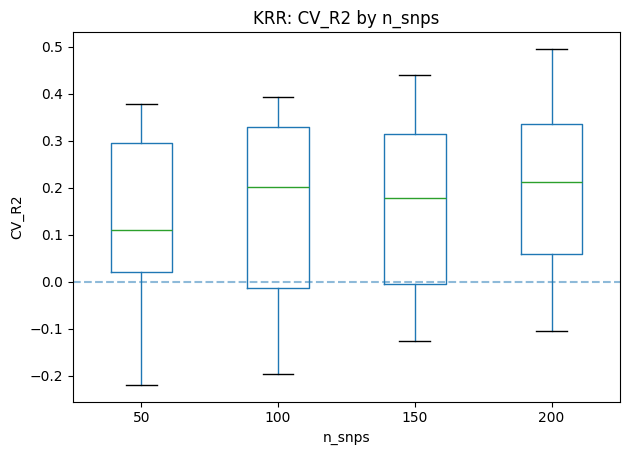

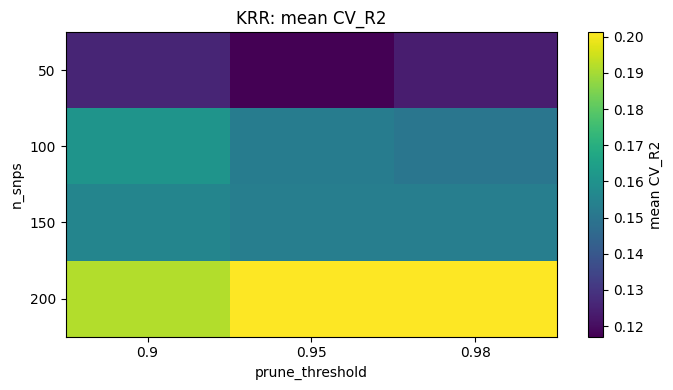

Best KRR per trait:


Trait,Model,CV_R2,RMSE,MAE,n_snps,prune_threshold
Phenol,KRR_RBF,0.4945345387530456,29540.80098389873,25035.80500606495,200,0.9
Butanoic acid,KRR_RBF,0.4034740361595963,49981.074683972256,37795.45887297569,200,0.9
Hexanoic acid,KRR_RBF,0.4034740361595947,49981.07468397232,37795.45887297593,200,0.9
Nonanal,KRR_RBF,0.3926717528443217,67597.74549271847,47080.85941974113,100,0.98
"Acetic acid, methyl ester",KRR_RBF,0.3917612032708539,245496.54501876733,179292.072670789,100,0.9
Benzoic acid,KRR_RBF,0.3850128145443191,22020.75596375891,15847.647853360017,200,0.95
"2-Propanone, 1-methoxy-",KRR_RBF,0.3788644623320372,898809.1455708952,709426.2373161456,50,0.98
Ethyl hexanoate,KRR_RBF,0.3749413707296277,31460.891664780876,24779.66120754012,200,0.95
Tridecane,KRR_RBF,0.3592422799333944,53061.90454149864,40487.87471689131,100,0.98
2-Methylpropanal,KRR_RBF,0.3589646641663259,115715.18375316836,79330.1444344977,150,0.95


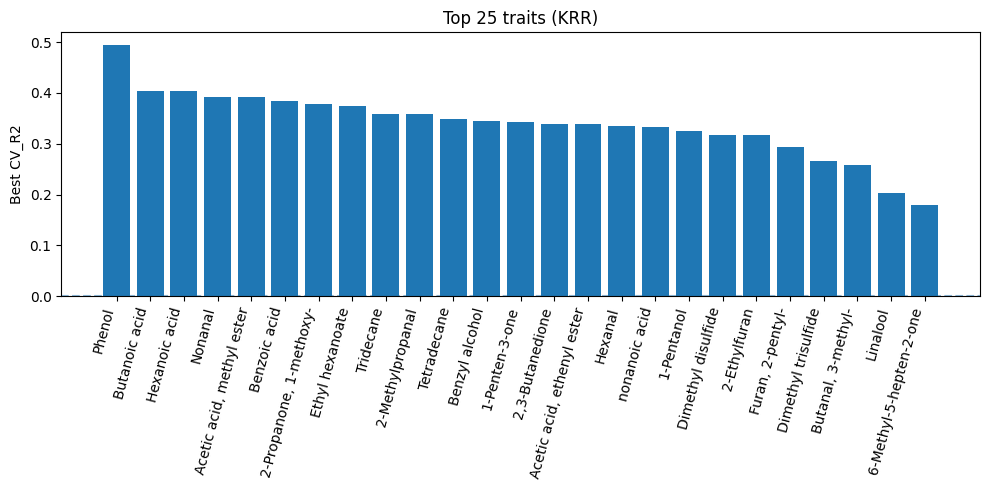

In [0]:


# =========================
# LOAD EXACT FILE (FIXED)
# =========================
path = "/Volumes/bmqg/default_bronze/fatemeh/final_project/model_results/krr_grid_20260320_192443.csv"

print("Loading:", path)
df = pd.read_csv(path)

# =========================
# CLEAN
# =========================
df = df.dropna(subset=["CV_R2"])

# =========================
# 1) BOXPLOT
# =========================
if "n_snps" in df.columns:

    plt.figure(figsize=(9,5))
    df.boxplot(column="CV_R2", by="n_snps", grid=False)

    plt.axhline(0, linestyle="--", alpha=0.5)
    plt.title("KRR: CV_R2 by n_snps")
    plt.suptitle("")
    plt.ylabel("CV_R2")

    plt.tight_layout()
    plt.show()

# =========================
# 2) HEATMAP
# =========================
if {"n_snps","prune_threshold"}.issubset(df.columns):

    g = (
        df.groupby(["n_snps","prune_threshold"])["CV_R2"]
        .mean()
        .reset_index()
    )

    pv = g.pivot(
        index="n_snps",
        columns="prune_threshold",
        values="CV_R2"
    ).sort_index()

    plt.figure(figsize=(7,4))
    plt.imshow(pv.values, aspect="auto")

    plt.xticks(range(len(pv.columns)), pv.columns)
    plt.yticks(range(len(pv.index)), pv.index)

    plt.colorbar(label="mean CV_R2")

    plt.xlabel("prune_threshold")
    plt.ylabel("n_snps")
    plt.title("KRR: mean CV_R2")

    plt.tight_layout()
    plt.show()

# =========================
# 3) BEST PER TRAIT
# =========================
trait_col = "Trait" if "Trait" in df.columns else "trait"

best = (
    df.loc[df.groupby(trait_col)["CV_R2"].idxmax()]
    .sort_values("CV_R2", ascending=False)
    .reset_index(drop=True)
)

print("Best KRR per trait:")
display(best.head(20))

# =========================
# 4) TOP TRAITS BARPLOT
# =========================
top = best.head(25)

plt.figure(figsize=(10,5))
plt.bar(top[trait_col], top["CV_R2"])

plt.axhline(0, linestyle="--", alpha=0.5)

plt.xticks(rotation=75, ha="right")
plt.ylabel("Best CV_R2")

plt.title("Top 25 traits (KRR)")
plt.tight_layout()
plt.show()

# Nonelinear models

In [0]:


N=[20,50,100,150,200]; P=[.90,.95,.98]
out_dir = "/Volumes/bmqg/default_bronze/fatemeh/final_project/model_results_newharvested/"
runs=[]
for p in P:
  for n in N:
    d=run_nonlinear_models_cv_nested_light_noleak(gwas_pd,GT,PH,n_snps=n,prune_threshold=p,n_splits=3,inner_splits=3,random_state=42)
    runs.append(d.assign(n_snps=n,prune_threshold=p))

res=pd.concat(runs,ignore_index=True)
res["CV_R2"]=pd.to_numeric(res["CV_R2"],errors="coerce")

t="Trait" if "Trait" in res.columns else "trait"
best=res.loc[res.groupby(t)["CV_R2"].idxmax()].sort_values("CV_R2",ascending=False).reset_index(drop=True)
best_m=res.loc[res.groupby([t,"Model"])["CV_R2"].idxmax()].sort_values("CV_R2",ascending=False).reset_index(drop=True)

ts=datetime.now().strftime("%Y%m%d_%H%M%S")
res.to_csv(f"{out_dir}/nonlinear_grid_{ts}.csv",index=False)
best.to_csv(f"{out_dir}/nonlinear_best_{ts}.csv",index=False)
best_m.to_csv(f"{out_dir}/nonlinear_best_by_model_{ts}.csv",index=False)


# Visualizing nonlinear results

n_snps,prune_threshold,Trait,Model,CV_R2,RMSE,MAE
50,0.9,1-Octen-3-ol,SVR,-0.1214755916564505,31027.930868951717,19296.50542650098
50,0.9,1-Octen-3-ol,RF,-0.10129800011689305,30747.536627560443,18776.80667859111
50,0.9,1-Octen-3-ol,XGB,0.1930036893094157,26320.4722273061,19421.460622479837
50,0.9,"2,3-Butanedione",SVR,-0.06481778731260013,528210.1302179038,425566.2823829003
50,0.9,"2,3-Butanedione",RF,0.14803597045272932,472475.949964064,364962.2605306806


<Figure size 700x500 with 0 Axes>

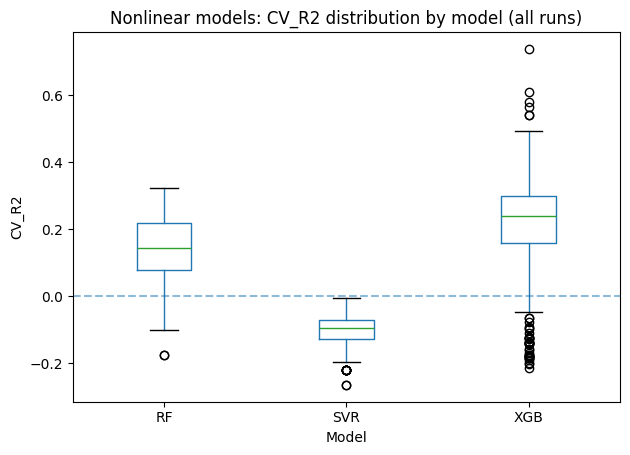

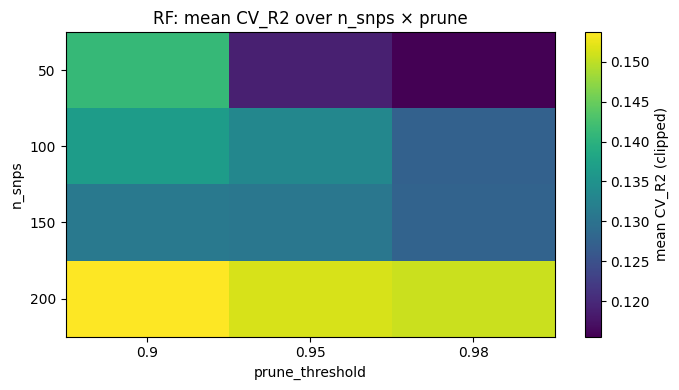

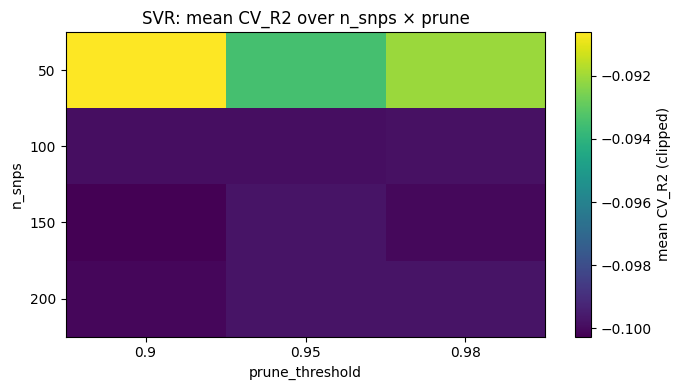

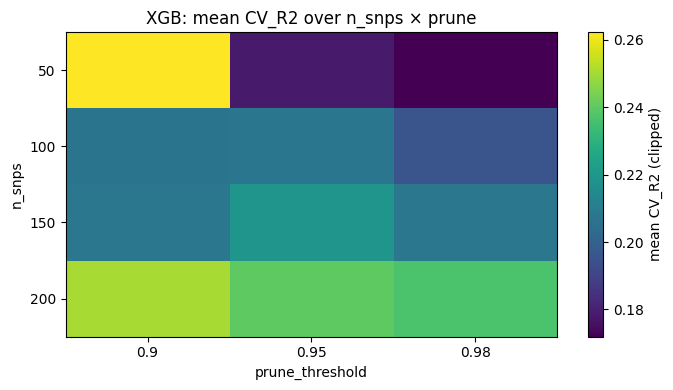

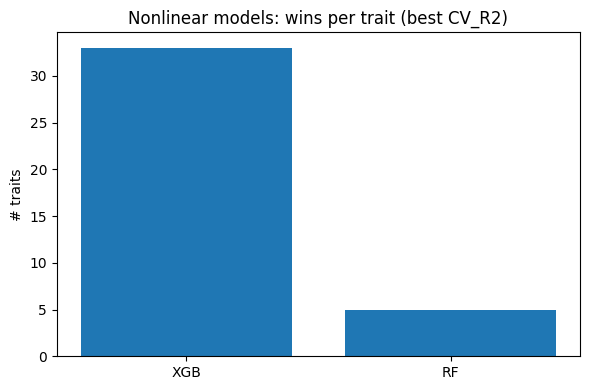

Best nonlinear per trait (top 20):


n_snps,prune_threshold,Trait,Model,CV_R2,RMSE,MAE
150,0.95,"Butanal, 3-methyl-",XGB,0.7373650339242172,61293.75491272541,36680.61328125
50,0.9,Decanal,XGB,0.5409408890997398,211726.33199688527,119777.49181547618
150,0.95,2-Ethylfuran,XGB,0.49167679443742596,255396.00408432022,175565.63560855263
50,0.95,"2-Propanone, 1-methoxy-",XGB,0.4729297198140937,827958.4792325896,638417.9641447369
100,0.95,Phenol,XGB,0.40691851816662616,31998.801043458727,25566.489638157895
150,0.9,"Acetic acid, methyl ester",XGB,0.3822596916816682,247406.60830291436,191137.6851973684
200,0.9,6-Methyl-5-hepten-2-one,XGB,0.36381506852669154,48561.39885465422,34199.728515625
50,0.95,1-Pentanol,XGB,0.3568493548566336,323724.9632519241,214072.0476310484
50,0.9,Benzaldehyde,XGB,0.3517979525361947,783772.9256291405,337362.83203125
150,0.9,Dimethyl disulfide,XGB,0.34796633791883524,224273.736664266,159061.31875


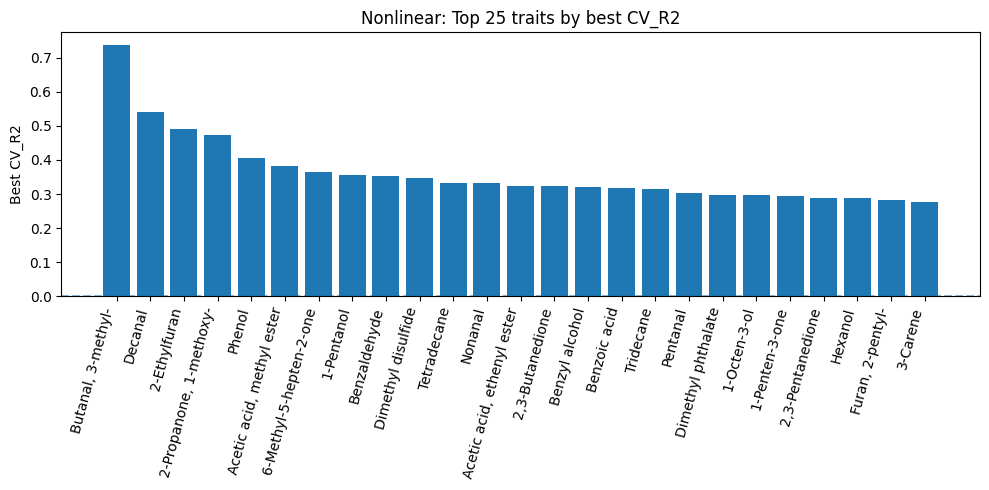

Best per trait per model (top 20):


n_snps,prune_threshold,Trait,Model,CV_R2,RMSE,MAE
150,0.95,"Butanal, 3-methyl-",XGB,0.7373650339242172,61293.75491272541,36680.61328125
50,0.9,Decanal,XGB,0.5409408890997398,211726.33199688527,119777.49181547618
150,0.95,2-Ethylfuran,XGB,0.49167679443742596,255396.00408432022,175565.63560855263
50,0.95,"2-Propanone, 1-methoxy-",XGB,0.4729297198140937,827958.4792325896,638417.9641447369
100,0.95,Phenol,XGB,0.40691851816662616,31998.801043458727,25566.489638157895
150,0.9,"Acetic acid, methyl ester",XGB,0.3822596916816682,247406.60830291436,191137.6851973684
200,0.9,6-Methyl-5-hepten-2-one,XGB,0.36381506852669154,48561.39885465422,34199.728515625
50,0.95,1-Pentanol,XGB,0.3568493548566336,323724.9632519241,214072.0476310484
50,0.9,Benzaldehyde,XGB,0.3517979525361947,783772.9256291405,337362.83203125
150,0.9,Dimethyl disulfide,XGB,0.34796633791883524,224273.736664266,159061.31875


In [0]:


# --- get dataframe (use res if exists, else load latest saved csv)
if "res" in globals() and isinstance(res, pd.DataFrame):
    df = res.copy()
else:
    paths = sorted(glob.glob(os.path.join(out_dir, "nonlinear_grid_*.csv")))
    if not paths:
        raise FileNotFoundError(f"No nonlinear_grid_*.csv found in {out_dir}")
    df = pd.read_csv(paths[-1])
    print("Loaded:", paths[-1], "| shape:", df.shape)

# --- clean columns
df["CV_R2"] = pd.to_numeric(df["CV_R2"], errors="coerce")
trait_col = "Trait" if "Trait" in df.columns else "trait"
model_col = "Model"  # your function writes "Model"

display(df.head())

# =========================
# 1) Boxplot: CV_R2 by model (all runs)
# =========================
plt.figure(figsize=(7,5))
df.boxplot(column="CV_R2", by=model_col, grid=False)
plt.axhline(0, linestyle="--", alpha=0.5)
plt.title("Nonlinear models: CV_R2 distribution by model (all runs)")
plt.suptitle("")
plt.ylabel("CV_R2")
plt.tight_layout()
plt.show()

# =========================
# 2) Heatmap per model: mean CV_R2 over n_snps × prune_threshold (clipped)
# =========================
def heatmap_model(d, title, lo=5, hi=95):
    g = (d.groupby(["n_snps","prune_threshold"])["CV_R2"]
           .mean()
           .reset_index())
    pv = g.pivot(index="n_snps", columns="prune_threshold", values="CV_R2").sort_index()
    Z = pv.to_numpy()

    vmin, vmax = np.nanpercentile(Z, lo), np.nanpercentile(Z, hi)

    plt.figure(figsize=(7,4))
    plt.imshow(Z, aspect="auto", vmin=vmin, vmax=vmax)
    plt.xticks(range(len(pv.columns)), pv.columns)
    plt.yticks(range(len(pv.index)), pv.index)
    plt.colorbar(label="mean CV_R2 (clipped)")
    plt.xlabel("prune_threshold"); plt.ylabel("n_snps")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for m in sorted(df[model_col].dropna().unique()):
    heatmap_model(df[df[model_col]==m], f"{m}: mean CV_R2 over n_snps × prune")

# =========================
# 3) Wins per trait (best run across all settings/models)
# =========================
best_idx = df.groupby(trait_col)["CV_R2"].idxmax()
best = (df.loc[best_idx]
          .sort_values("CV_R2", ascending=False)
          .reset_index(drop=True))

wins = best[model_col].value_counts()

plt.figure(figsize=(6,4))
plt.bar(wins.index, wins.values)
plt.title("Nonlinear models: wins per trait (best CV_R2)")
plt.ylabel("# traits")
plt.tight_layout()
plt.show()

print("Best nonlinear per trait (top 20):")
display(best.head(20))

# =========================
# 4) Top 25 traits by best CV_R2 (overall)
# =========================
top = best.head(25)
plt.figure(figsize=(10,5))
plt.bar(top[trait_col], top["CV_R2"])
plt.axhline(0, linestyle="--", alpha=0.5)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Best CV_R2")
plt.title("Nonlinear: Top 25 traits by best CV_R2")
plt.tight_layout()
plt.show()

# =========================
# 5)  best-per-trait-per-model table (like your best_m)
# =========================
best_m = (df.loc[df.groupby([trait_col, model_col])["CV_R2"].idxmax()]
            .sort_values("CV_R2", ascending=False)
            .reset_index(drop=True))

print("Best per trait per model (top 20):")
display(best_m.head(20))


“Across traits, Ridge regression provided the most robust overall performance, while KRR occasionally outperformed linear models for specific compounds, suggesting trait-specific nonlinearity. Tree-based models showed higher variance and less consistent generalisation under nested CV.”